## JTWC WP0426 - Phan tich du lieu va render bao

Notebook nay lam 2 viec:
1. Hien thi cau truc va noi dung cua file KMZ `data/tropical_cyclone/JTWC/wp0426.kmz`.
2. Doc du lieu thuc te va render map bao (giong flow trong `nhc.ipynb`).

In [1]:

import cloudscraper
import xml.etree.ElementTree as ET

def bypass_403():
    # Tạo scraper giả lập Chrome trên Windows
    scraper = cloudscraper.create_scraper(browser={'browser': 'chrome', 'platform': 'windows', 'mobile': False})
    
    
    url = "https://www.metoc.navy.mil/jtwc/jtwc.rss"
    #url = "https://s3.amazonaws.com/www.metoc.navy.mil/jtwc/jtwc.rss"
    #
    try:
        response = scraper.get(url, timeout=20)
        if response.status_code == 200:
            print("✅ Vượt rào thành công!")
            root = ET.fromstring(response.content)
            # Tiếp tục xử lý như cũ...
        else:
            print(f"❌ Vẫn bị lỗi {response.status_code}")
    except Exception as e:
        print(f"💥 Lỗi: {e}")

bypass_403()

❌ Vẫn bị lỗi 403


In [3]:
import requests
import xml.etree.ElementTree as ET
from bs4 import BeautifulSoup

def get_storm_data():
    url = "https://www.metoc.navy.mil/jtwc/jtwc.rss"
    
    # Bộ Header đầy đủ để "giả dạng" trình duyệt Chrome
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9,vi;q=0.8",
        "Referer": "https://www.metoc.navy.mil/jtwc/jtwc.html",
        "Connection": "keep-alive"
    }

    try:
        # Sử dụng session để giữ cookie nếu cần
        session = requests.Session()
        response = session.get(url, headers=headers, timeout=20)
        
        # Kiểm tra lỗi HTTP
        if response.status_code == 403:
            print("❌ Vẫn bị lỗi 403. Server đang chặn gắt dải IP này. Thử bật VPN sang Mỹ nhé Minh!")
            return
        
        response.raise_for_status()
        root = ET.fromstring(response.content)

        # Định nghĩa danh mục các khu vực
        regions = {
            "NWPAC-NIO-WARNINGS": "🌏 WEST PACIFIC (Biển Đông & Nhật Bản)",
            "EPAC-CPAC-WARNINGS": "🌊 CENTRAL/EAST PACIFIC",
            "SH-WARNINGS": "🇦🇺 SOUTHERN HEMISPHERE (Úc & Nam Ấn Độ Dương)",
            "TROPICAL-ADVISORIES": "⚠️ ADVISORIES (Vùng đang theo dõi)"
        }

        print(f"{'='*80}")
        print(f"📊 BÁO CÁO DỮ LIỆU BÃO THEO KHU VỰC")
        print(f"📅 Cập nhật: {root.find('.//pubDate').text}")
        print(f"{'='*80}\n")

        # Duyệt qua từng khu vực mục tiêu
        for guid_id, region_name in regions.items():
            print(f"📍 KHU VỰC: {region_name}")
            found = False

            for item in root.findall('.//item'):
                guid = item.find('guid').text if item.find('guid') is not None else ""
                
                if guid == guid_id:
                    description = item.find('description').text
                    soup = BeautifulSoup(description, 'html.parser')
                    
                    # Lấy text nội dung bản tin
                    content = soup.get_text(separator=' ').strip()
                    
                    if "No Current Tropical" in content:
                        print("   ✅ Hiện tại không có bão hoạt động.")
                    else:
                        found = True
                        # Trích xuất tiêu đề cơn bão
                        storm_name = content.split('\n')[0].strip()
                        print(f"   🌀 Phát hiện: {storm_name}")
                        
                        # Liệt kê các link dữ liệu
                        for a in soup.find_all('a', href=True):
                            label = a.text.strip()
                            url_link = a['href']
                            if url_link.endswith('.kmz'):
                                print(f"      🔗 KMZ Overlay: {url_link}")
                            elif 'web.txt' in url_link:
                                print(f"      📄 Bản tin chữ: {url_link}")
                    break
            
            print(f"{'-'*80}")

    except Exception as e:
        print(f"💥 Lỗi hệ thống: {e}")

if __name__ == "__main__":
    get_storm_data()

❌ Vẫn bị lỗi 403. Server đang chặn gắt dải IP này. Thử bật VPN sang Mỹ nhé Minh!


In [16]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET
from collections import Counter
from html import unescape

from IPython.display import display, Markdown


def find_workspace_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "tropical_cyclone").exists():
            return p
    raise FileNotFoundError("Khong tim thay thu muc data/tropical_cyclone")


def local_name(tag: str) -> str:
    return tag.split("}", 1)[-1] if "}" in tag else tag


def first_descendant_by_name(root: ET.Element, name: str):
    for elem in root.iter():
        if local_name(elem.tag) == name:
            return elem
    return None


def parse_coords_list(text: str):
    pts = []
    for token in text.strip().split():
        lon, lat, *_ = token.split(",")
        pts.append((float(lat), float(lon)))
    return pts


def parse_description_table(description_html: str):
    if not description_html:
        return {}

    text = unescape(description_html).replace("&nbsp;", " ")
    pattern = re.compile(
        r"<tr>\s*<td>\s*(?:<b>)?(.*?)(?:</b>)?\s*</td>\s*<td>\s*(?:<b>)?(.*?)(?:</b>)?\s*</td>\s*</tr>",
        flags=re.IGNORECASE | re.DOTALL,
    )

    out = {}
    for k, v in pattern.findall(text):
        key = re.sub(r"<.*?>", "", k)
        val = re.sub(r"<.*?>", "", v)
        key = " ".join(key.split())
        val = " ".join(val.split())
        if key:
            out[key] = val
    return out


def extract_kml_root(kmz_path: Path) -> ET.Element:
    with zipfile.ZipFile(kmz_path, "r") as zf:
        kml_name = next((n for n in zf.namelist() if n.lower().endswith(".kml")), None)
        if not kml_name:
            raise ValueError(f"Khong tim thay KML trong {kmz_path.name}")
        return ET.fromstring(zf.read(kml_name))


def walk_placemarks(node: ET.Element, folder_name: str = ""):
    tag = local_name(node.tag)

    if tag == "Folder":
        folder_child = next((c for c in node if local_name(c.tag) == "name" and c.text), None)
        this_name = folder_child.text.strip() if folder_child is not None else ""
        active_folder = this_name or folder_name
        for ch in node:
            yield from walk_placemarks(ch, active_folder)
        return

    if tag == "Placemark":
        yield folder_name, node
        return

    for ch in node:
        yield from walk_placemarks(ch, folder_name)


def read_placemark_record(folder: str, pm: ET.Element):
    def get_text(name: str):
        e = first_descendant_by_name(pm, name)
        return e.text.strip() if (e is not None and e.text) else ""

    name = get_text("name")
    style = get_text("styleUrl")
    description = get_text("description")
    table = parse_description_table(description)

    geometry = "Unknown"
    lat = None
    lon = None
    coords = []

    point_node = first_descendant_by_name(pm, "Point")
    line_node = first_descendant_by_name(pm, "LineString")
    poly_node = first_descendant_by_name(pm, "Polygon")

    if point_node is not None:
        geometry = "Point"
        c = first_descendant_by_name(point_node, "coordinates")
        if c is not None and c.text:
            pts = parse_coords_list(c.text)
            if pts:
                lat, lon = pts[0]
                coords = pts
    elif line_node is not None:
        geometry = "LineString"
        c = first_descendant_by_name(line_node, "coordinates")
        if c is not None and c.text:
            coords = parse_coords_list(c.text)
    elif poly_node is not None:
        geometry = "Polygon"
        c = first_descendant_by_name(poly_node, "coordinates")
        if c is not None and c.text:
            coords = parse_coords_list(c.text)

    return {
        "folder": folder,
        "name": name,
        "style": style,
        "geometry": geometry,
        "lat": lat,
        "lon": lon,
        "coords": coords,
        "table": table,
        "description": description,
    }


workspace_root = find_workspace_root(Path.cwd())
kmz_path = workspace_root / "data" / "tropical_cyclone" / "JTWC" / "wp0426.kmz"

with zipfile.ZipFile(kmz_path, "r") as zf:
    entries = zf.namelist()

root = extract_kml_root(kmz_path)
records = [read_placemark_record(folder, pm) for folder, pm in walk_placemarks(root)]

display(Markdown("### 1) Trong KMZ nay co gi?"))
print("File KMZ:", kmz_path)
print("So file ben trong KMZ:", len(entries))
print("Danh sach entry:")
for n in entries:
    print(" -", n)

folder_counts = Counter(r["folder"] or "(root)" for r in records)
geom_counts = Counter(r["geometry"] for r in records)
style_counts = Counter(r["style"] for r in records if r["style"])

print("\nTong so Placemark:", len(records))
print("Thong ke theo folder:")
for k, v in folder_counts.items():
    print(f" - {k}: {v}")

print("\nThong ke theo geometry:")
for k, v in geom_counts.items():
    print(f" - {k}: {v}")

print("\nThong ke styleUrl (top):")
for k, v in style_counts.most_common(10):
    print(f" - {k}: {v}")

sample_rows = []
for r in records[:12]:
    sample_rows.append({
        "folder": r["folder"],
        "name": r["name"],
        "geometry": r["geometry"],
        "style": r["style"],
        "lat": r["lat"],
        "lon": r["lon"],
        "desc_fields": ", ".join(sorted(r["table"].keys())),
    })

display(Markdown("### Mau 12 Placemark dau tien"))
try:
    import pandas as pd
    display(pd.DataFrame(sample_rows))
except Exception:
    for row in sample_rows:
        print(row)

all_fields = Counter()
field_values = {}
for r in records:
    for k, v in r["table"].items():
        all_fields[k] += 1
        field_values.setdefault(k, set()).add(v)

display(Markdown("### 2) Cac truong thong tin tim duoc trong description table"))
if not all_fields:
    print("Khong tim thay bang field trong description.")
else:
    for k in sorted(all_fields):
        vals = sorted(field_values[k])
        pv = ", ".join(vals[:3])
        if len(vals) > 3:
            pv += f" ...(+{len(vals)-3})"
        print(f" - {k}: xuat hien {all_fields[k]} lan | mau: {pv}")

display(Markdown("### 3) Giai thich cau truc du lieu"))
display(Markdown(
    "- Kieu du lieu: **KMZ (zip)**, ben trong co `doc.kml` va thu muc `images/`.\n"
    "- KML to chuc theo cay: `Document -> Folder -> Placemark`.\n"
    "- Moi `Placemark` chua mot geometry (`Point`/`LineString`/`Polygon`) va `styleUrl`.\n"
    "- Metadata nghiep vu (ten bao, thoi gian, gio, huong di chuyen...) nam trong `description` duoi dang bang HTML."
))

field_explain = {
    "NAME": "Ten bao (vi du: SINLAKU).",
    "WRNG NMBR": "So warning bulletin cua JTWC.",
    "TIME": "Moc thoi gian/forecast tau (vi du TAU 12, TAU 24).",
    "POSIT": "Vi tri tam bao o dang lat/lon.",
    "WIND SPD": "Toc do gio duy tri (don vi knots).",
    "MOVEMENT": "Huong va toc do di chuyen (vd 085 DEG AT 22 KTS).",
}

display(Markdown("### 4) Giai thich y nghia cac truong"))
for k in sorted(all_fields):
    print(f" - {k}: {field_explain.get(k, 'Chua co mo ta mapping cu the, can doi chieu tai lieu JTWC.')}")

### 1) Trong KMZ nay co gi?

File KMZ: d:\Work\Learn\HK6_2025-2026\flutter\Search_Wheather_forecast\data\tropical_cyclone\JTWC\wp0426.kmz
So file ben trong KMZ: 13
Danh sach entry:
 - doc.kml
 - images/JTWCtranslogo.png
 - images/LOW.png
 - images/TD.png
 - images/TDgray.png
 - images/TS.png
 - images/TSgray.png
 - images/TSSH.png
 - images/TSgraySH.png
 - images/TY.png
 - images/TYgray.png
 - images/TYSH.png
 - images/TYgraySH.png

Tong so Placemark: 68
Thong ke theo folder:
 - Forecast: 10
 - Previous Best Track Posits: 58

Thong ke theo geometry:
 - Point: 60
 - Polygon: 6
 - LineString: 2

Thong ke styleUrl (top):
 - #BestTrackStyle0: 31
 - #BestTrackStyle1: 17
 - #BestTrackStyle5: 9
 - #TropicalBalloonStyle: 4
 - #WindRadii34: 3
 - #WindRadii50: 2
 - #msn_ylw-pushpin: 1
 - #BestTrack: 1


### Mau 12 Placemark dau tien

,folder,name,geometry,style,lat,lon,desc_fields
0,Forecast,19/18Z (TROPICAL STORM 04W (SINLAKU) WARNING N...,Point,#TropicalBalloonStyle,28.7,156.1,
1,Forecast,RADIUS OF 34 KT WINDS,Polygon,#WindRadii34,NaN,NaN,
2,Forecast,RADIUS OF 50 KT WINDS,Polygon,#WindRadii50,NaN,NaN,
3,Forecast,20/06Z - 50 knots,Point,#TropicalBalloonStyle,29.4,161.1,"MOVEMENT, NAME, POSIT, TIME, WIND SPD, WRNG NMBR"
4,Forecast,RADIUS OF 34 KT WINDS,Polygon,#WindRadii34,NaN,NaN,
5,Forecast,RADIUS OF 50 KT WINDS,Polygon,#WindRadii50,NaN,NaN,
6,Forecast,20/18Z - 45 knots,Point,#TropicalBalloonStyle,29.5,166.1,"MOVEMENT, NAME, POSIT, TIME, WIND SPD, WRNG NMBR"
7,Forecast,RADIUS OF 34 KT WINDS,Polygon,#WindRadii34,NaN,NaN,
8,Forecast,wp04 Storm Track,LineString,#TropicalBalloonStyle,NaN,NaN,
9,Forecast,34 knot Danger Swath,Polygon,#msn_ylw-pushpin,NaN,NaN,


### 2) Cac truong thong tin tim duoc trong description table

 - MOVEMENT: xuat hien 2 lan | mau: , 085 DEG AT 22 KTS
 - NAME: xuat hien 2 lan | mau: SINLAKU
 - POSIT: xuat hien 2 lan | mau: 29.4 N, 161.1 E, 29.5 N, 166.1 E
 - TIME: xuat hien 2 lan | mau: TAU 12 - 2026042006Z, TAU 24 - 2026042018Z
 - WIND SPD: xuat hien 2 lan | mau: 45 KTS, 50 KTS
 - WRNG NMBR: xuat hien 2 lan | mau: 44


### 3) Giai thich cau truc du lieu

- Kieu du lieu: **KMZ (zip)**, ben trong co `doc.kml` va thu muc `images/`.
- KML to chuc theo cay: `Document -> Folder -> Placemark`.
- Moi `Placemark` chua mot geometry (`Point`/`LineString`/`Polygon`) va `styleUrl`.
- Metadata nghiep vu (ten bao, thoi gian, gio, huong di chuyen...) nam trong `description` duoi dang bang HTML.

### 4) Giai thich y nghia cac truong

 - MOVEMENT: Huong va toc do di chuyen (vd 085 DEG AT 22 KTS).
 - NAME: Ten bao (vi du: SINLAKU).
 - POSIT: Vi tri tam bao o dang lat/lon.
 - TIME: Moc thoi gian/forecast tau (vi du TAU 12, TAU 24).
 - WIND SPD: Toc do gio duy tri (don vi knots).
 - WRNG NMBR: So warning bulletin cua JTWC.



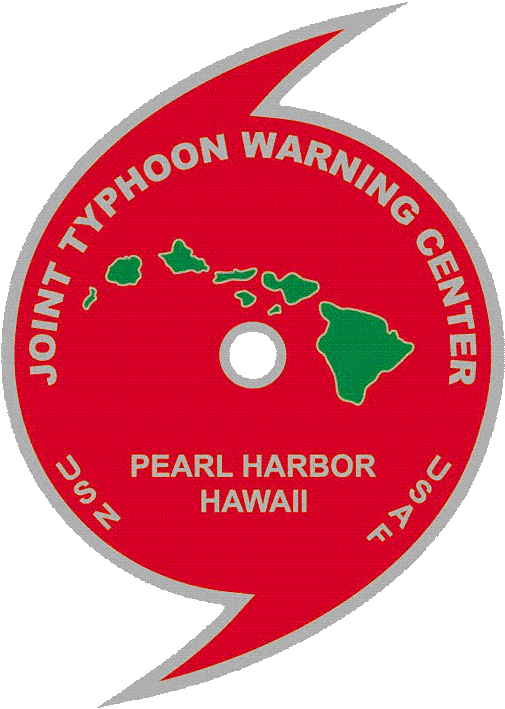
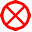
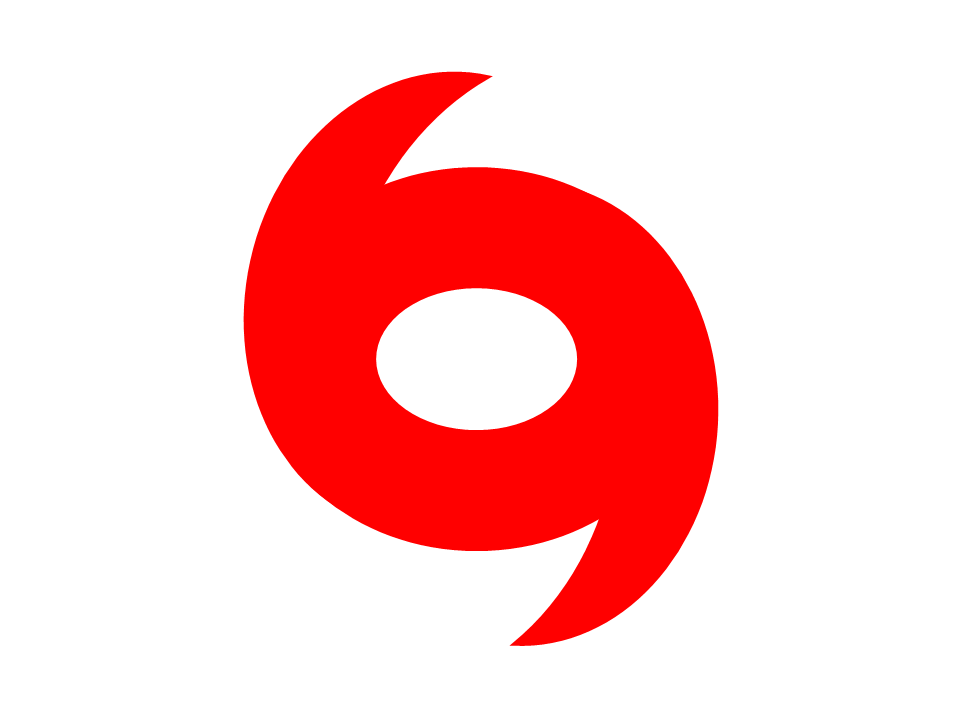
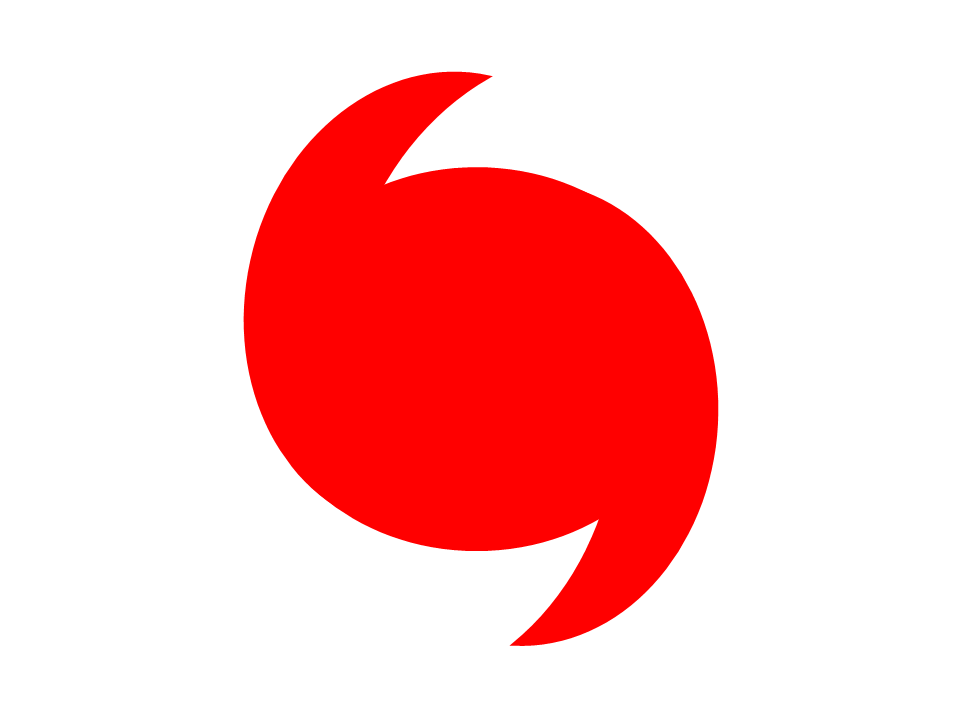

Da su dung icon PNG tu: d:\Work\Learn\HK6_2025-2026\flutter\Search_Wheather_forecast\data\tropical_cyclone\JTWC\wp0426\images
Da luu map HTML tai: d:\Work\Learn\HK6_2025-2026\flutter\Search_Wheather_forecast\maps\tropical_cyclone\jtwc_wp0426_map.html



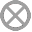
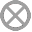
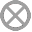
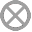
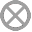
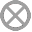
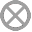
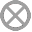
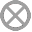
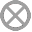
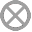
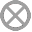
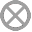
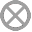
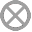
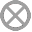
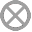
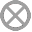
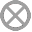
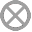
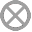
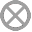
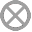
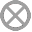
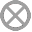
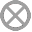
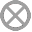
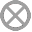
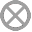
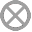
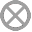
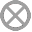
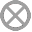
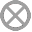
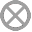
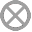
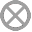
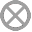
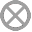
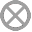
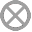
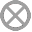
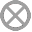
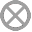
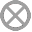
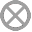
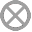
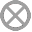
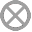
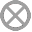
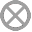
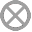
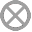
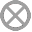
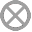
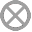
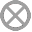
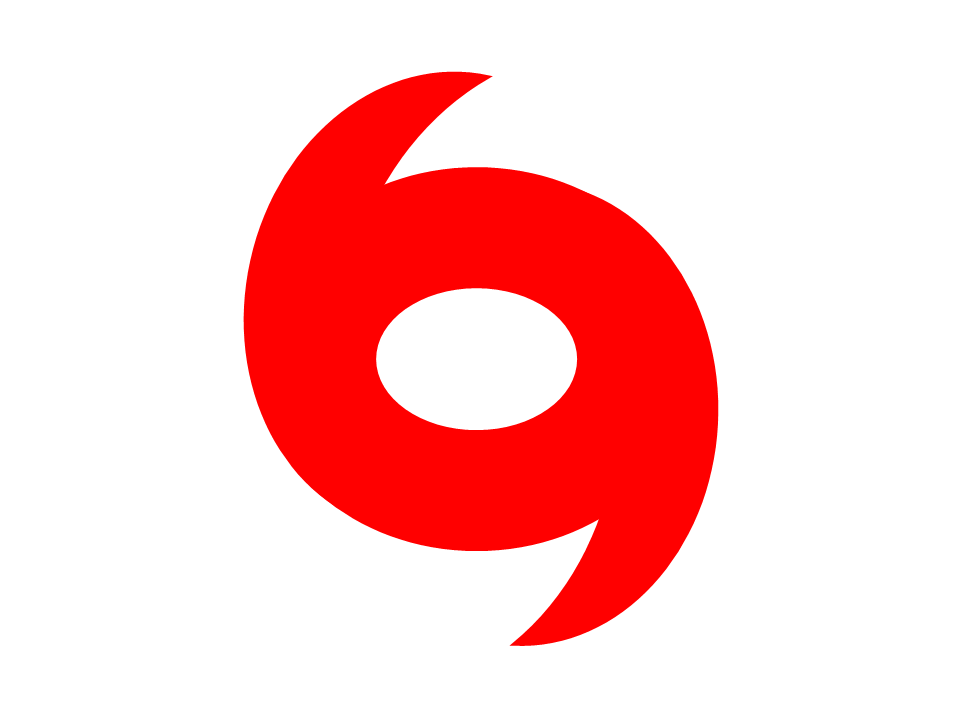
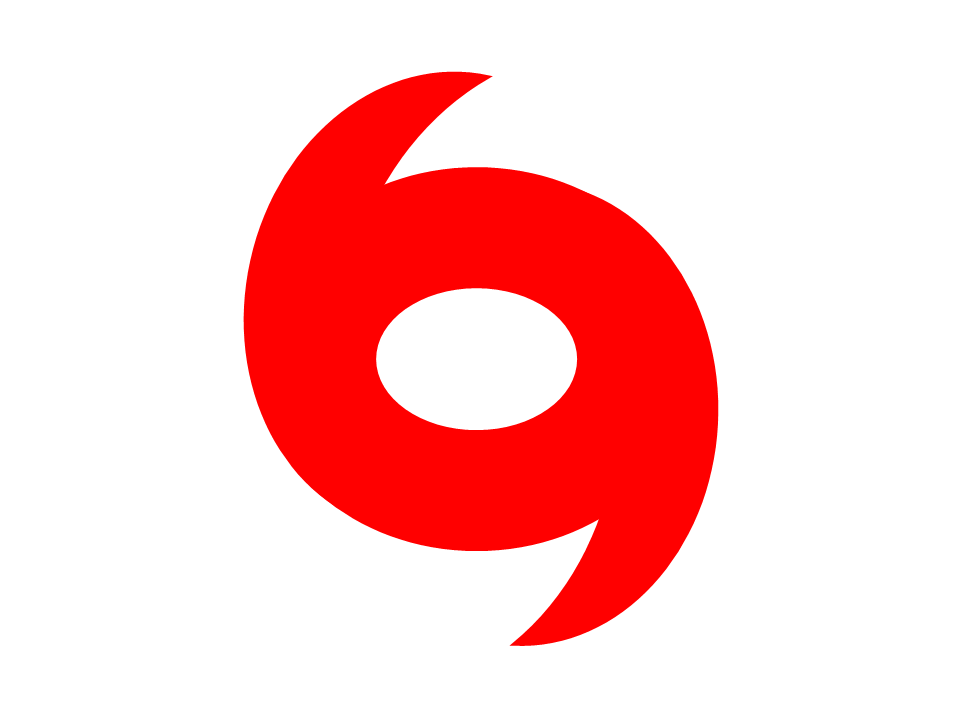
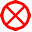

In [5]:
import base64
import math
import zipfile
from datetime import datetime

import folium
from folium.plugins import Fullscreen, MiniMap, MousePosition, AntPath
from IPython.display import HTML


def to_dt_best_track(name: str):
    # Vi du name: 26041912Z -> yy mm dd hh Z
    m = re.match(r"^(\d{2})(\d{2})(\d{2})(\d{2})Z$", (name or "").strip())
    if not m:
        return None
    yy, mo, dd, hh = map(int, m.groups())
    return datetime(2000 + yy, mo, dd, hh)


def parse_tau_from_time(text: str):
    m = re.search(r"TAU\s*(\d+)", text or "", flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def parse_wind_knots(text: str):
    m = re.search(r"(\d+)\s*KTS", text or "", flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def classify_icon(wind_kt: int | None, gray: bool = False):
    if wind_kt is None:
        base = "TD"
    elif wind_kt >= 64:
        base = "TY"
    elif wind_kt >= 34:
        base = "TS"
    elif wind_kt > 0:
        base = "TD"
    else:
        base = "LOW"

    if gray and base in {"TD", "TS", "TY"}:
        return f"{base}gray.png"
    return f"{base}.png"


def ensure_icon_folder() -> Path:
    icon_dir = workspace_root / "data" / "tropical_cyclone" / "JTWC" / "wp0426" / "images"
    if icon_dir.exists():
        return icon_dir

    icon_dir.mkdir(parents=True, exist_ok=True)
    kmz_file = workspace_root / "data" / "tropical_cyclone" / "JTWC" / "wp0426.kmz"
    with zipfile.ZipFile(kmz_file, "r") as zf:
        for n in zf.namelist():
            if n.lower().startswith("images/") and n.lower().endswith(".png"):
                zf.extract(n, path=workspace_root / "data" / "tropical_cyclone" / "JTWC" / "wp0426")
    return icon_dir


def icon_data_uri(icon_dir: Path, icon_name: str):
    p = icon_dir / icon_name
    if not p.exists():
        return None
    b64 = base64.b64encode(p.read_bytes()).decode("ascii")
    return f"data:image/png;base64,{b64}"


def build_marker_icon(icon_dir: Path, icon_name: str, size: int = 26):
    uri = icon_data_uri(icon_dir, icon_name)
    if not uri:
        return None
    return folium.CustomIcon(icon_image=uri, icon_size=(size, size), icon_anchor=(size // 2, size // 2))


def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlon / 2) ** 2
    return 2 * r * math.atan2(math.sqrt(a), math.sqrt(1 - a))


icon_dir = ensure_icon_folder()

forecast_points = [r for r in records if r["folder"] == "Forecast" and r["geometry"] == "Point"]
best_track_points = [r for r in records if r["folder"] == "Previous Best Track Posits" and r["geometry"] == "Point"]

forecast_lines = [r for r in records if r["folder"] == "Forecast" and r["geometry"] == "LineString"]
best_track_lines = [r for r in records if r["geometry"] == "LineString" and r["style"] == "#BestTrack"]

poly_34 = [r for r in records if r["geometry"] == "Polygon" and r["style"] == "#WindRadii34"]
poly_50 = [r for r in records if r["geometry"] == "Polygon" and r["style"] == "#WindRadii50"]
danger_swath = [r for r in records if r["geometry"] == "Polygon" and r["style"] == "#msn_ylw-pushpin"]

for p in forecast_points:
    p["tau"] = parse_tau_from_time(p["table"].get("TIME", ""))
    p["wind_kt"] = parse_wind_knots(p["table"].get("WIND SPD", ""))
for p in best_track_points:
    p["wind_kt"] = parse_wind_knots(p["table"].get("WIND SPD", ""))

forecast_points.sort(key=lambda x: (9999 if x["tau"] is None else x["tau"], x["name"]))
best_track_points.sort(key=lambda x: (to_dt_best_track(x["name"]) or datetime.max))

if forecast_points:
    center = [forecast_points[0]["lat"], forecast_points[0]["lon"]]
elif best_track_points:
    center = [best_track_points[-1]["lat"], best_track_points[-1]["lon"]]
else:
    raise RuntimeError("Khong co diem de ve map")

all_lats = [r["lat"] for r in forecast_points + best_track_points if r["lat"] is not None]
all_lons = [r["lon"] for r in forecast_points + best_track_points if r["lon"] is not None]
for arr in [poly_34, poly_50, danger_swath, forecast_lines, best_track_lines]:
    for r in arr:
        all_lats.extend([lat for lat, _ in r["coords"]])
        all_lons.extend([lon for _, lon in r["coords"]])

m = folium.Map(location=center, zoom_start=4, tiles="CartoDB Voyager", control_scale=True)
Fullscreen(position="topleft", title="Full screen", title_cancel="Exit full screen").add_to(m)
MiniMap(toggle_display=True).add_to(m)
MousePosition(position="bottomleft").add_to(m)

layer_best = folium.FeatureGroup(name="Best track history", show=True)
if best_track_lines:
    folium.PolyLine(best_track_lines[0]["coords"], color="#334155", weight=3, opacity=0.9, tooltip="JTWC Best Track").add_to(layer_best)
else:
    coords = [(r["lat"], r["lon"]) for r in best_track_points]
    if len(coords) >= 2:
        folium.PolyLine(coords, color="#334155", weight=3, opacity=0.9, tooltip="JTWC Best Track").add_to(layer_best)

for p in best_track_points:
    icon_name = classify_icon(p.get("wind_kt"), gray=True)
    custom_icon = build_marker_icon(icon_dir, icon_name, size=22)
    popup_html = (
        f"<b>{p['table'].get('NAME', 'N/A')}</b><br>"
        f"Time: {p['name']}<br>"
        f"Position: {p['table'].get('POSIT', 'N/A')}<br>"
        f"Wind: {p['table'].get('WIND SPD', 'N/A')}<br>"
        f"Move: {p['table'].get('MOVEMENT', 'N/A')}"
    )
    if custom_icon:
        folium.Marker(
            location=(p["lat"], p["lon"]),
            icon=custom_icon,
            popup=folium.Popup(popup_html, max_width=320),
        ).add_to(layer_best)
    else:
        folium.CircleMarker(
            location=(p["lat"], p["lon"]),
            radius=4,
            color="#475569",
            fill=True,
            fill_color="#94a3b8",
            fill_opacity=0.9,
            popup=folium.Popup(popup_html, max_width=320),
        ).add_to(layer_best)
layer_best.add_to(m)

layer_forecast = folium.FeatureGroup(name="Forecast track", show=True)
if forecast_lines:
    AntPath(
        locations=forecast_lines[0]["coords"],
        color="#2563eb",
        delay=850,
        weight=4,
        pulse_color="#93c5fd",
        tooltip="JTWC Forecast Track",
    ).add_to(layer_forecast)
else:
    coords = [(r["lat"], r["lon"]) for r in forecast_points]
    if len(coords) >= 2:
        AntPath(locations=coords, color="#2563eb", delay=850, weight=4, pulse_color="#93c5fd").add_to(layer_forecast)

for p in forecast_points:
    tau_text = "Initial" if p["tau"] is None else f"+{p['tau']}h"
    icon_name = classify_icon(p.get("wind_kt"), gray=False)
    icon_size = 34 if p["tau"] is None else 28
    custom_icon = build_marker_icon(icon_dir, icon_name, size=icon_size)
    popup_html = (
        f"<b>{p['table'].get('NAME', 'N/A')}</b><br>"
        f"Warning: {p['table'].get('WRNG NMBR', 'N/A')}<br>"
        f"Time: {p['table'].get('TIME', p['name'])}<br>"
        f"Forecast: {tau_text}<br>"
        f"Position: {p['table'].get('POSIT', 'N/A')}<br>"
        f"Wind: {p['table'].get('WIND SPD', 'N/A')}<br>"
        f"Move: {p['table'].get('MOVEMENT', 'N/A')}"
    )
    if custom_icon:
        folium.Marker(
            location=(p["lat"], p["lon"]),
            icon=custom_icon,
            popup=folium.Popup(popup_html, max_width=340),
            tooltip=tau_text,
        ).add_to(layer_forecast)
    else:
        is_initial = p["tau"] is None
        folium.CircleMarker(
            location=(p["lat"], p["lon"]),
            radius=8 if is_initial else 6,
            color="#7f1d1d" if is_initial else "#1d4ed8",
            fill=True,
            fill_color="#ef4444" if is_initial else "#60a5fa",
            fill_opacity=0.95,
            popup=folium.Popup(popup_html, max_width=340),
        ).add_to(layer_forecast)
layer_forecast.add_to(m)

layer_wind = folium.FeatureGroup(name="Wind radii / danger", show=True)
for pg in poly_34:
    if pg["coords"]:
        folium.Polygon(
            pg["coords"],
            color="#16a34a",
            weight=1.8,
            fill=True,
            fill_color="#22c55e",
            fill_opacity=0.16,
            tooltip="Radius 34 kt",
        ).add_to(layer_wind)
for pg in poly_50:
    if pg["coords"]:
        folium.Polygon(
            pg["coords"],
            color="#ca8a04",
            weight=1.8,
            fill=True,
            fill_color="#facc15",
            fill_opacity=0.18,
            tooltip="Radius 50 kt",
        ).add_to(layer_wind)
for pg in danger_swath:
    if pg["coords"]:
        folium.Polygon(
            pg["coords"],
            color="#9333ea",
            weight=2,
            fill=True,
            fill_color="#c084fc",
            fill_opacity=0.12,
            tooltip="34 kt danger swath",
        ).add_to(layer_wind)
layer_wind.add_to(m)

if all_lats and all_lons:
    m.fit_bounds([[min(all_lats), min(all_lons)], [max(all_lats), max(all_lons)]])
folium.LayerControl(collapsed=False).add_to(m)

# Mot so thong ke nhanh cho panel thong tin
move_speed = None
if len(best_track_points) >= 2:
    p1 = best_track_points[-2]
    p2 = best_track_points[-1]
    dist_km = haversine_km(p1["lat"], p1["lon"], p2["lat"], p2["lon"])
    t1 = to_dt_best_track(p1["name"])
    t2 = to_dt_best_track(p2["name"])
    if t1 and t2 and t2 > t1:
        move_speed = dist_km / ((t2 - t1).total_seconds() / 3600.0)

latest = forecast_points[0] if forecast_points else best_track_points[-1]
logo_uri = icon_data_uri(icon_dir, "JTWCtranslogo.png") or ""

legend_items = [
    ("LOW", "LOW.png"),
    ("TD", "TD.png"),
    ("TS", "TS.png"),
    ("TY", "TY.png"),
]
legend_html = ""
for label, icon_name in legend_items:
    u = icon_data_uri(icon_dir, icon_name)
    if u:
        legend_html += f"<div style='display:flex;align-items:center;gap:8px;margin-top:4px;'><img src='{u}' width='20' height='20'/><span>{label}</span></div>"

info_html = f"""
<div style='font-family: Segoe UI, Arial, sans-serif; background: linear-gradient(120deg,#0f172a,#1d4ed8); color: #f8fafc; padding: 14px 16px; border-radius: 12px; margin: 8px 0 14px 0;'>
  <div style='display:flex; align-items:center; justify-content:space-between; gap:10px;'>
    <h3 style='margin:0; font-size:18px;'>JTWC WP0426 Storm Summary</h3>
    {f"<img src='{logo_uri}' width='70'/>" if logo_uri else ''}
  </div>
  <div><b>Name:</b> {latest['table'].get('NAME', 'N/A')}</div>
  <div><b>Warning number:</b> {latest['table'].get('WRNG NMBR', 'N/A')}</div>
  <div><b>Latest point time:</b> {latest['table'].get('TIME', latest['name'])}</div>
  <div><b>Wind speed:</b> {latest['table'].get('WIND SPD', 'N/A')}</div>
  <div><b>Movement:</b> {latest['table'].get('MOVEMENT', 'N/A')}</div>
  <div><b>Forecast points:</b> {len(forecast_points)}</div>
  <div><b>Best-track points:</b> {len(best_track_points)}</div>
  <div><b>Estimated recent translation:</b> {f'{move_speed:.1f} km/h' if move_speed is not None else 'N/A'}</div>
  <hr style='border-color: rgba(255,255,255,0.25); margin:8px 0;' />
  <div><b>Icon legend</b></div>
  {legend_html}
</div>
"""
display(HTML(info_html))

out_html = workspace_root / "maps" / "tropical_cyclone" / "jtwc_wp0426_map.html"
out_html.parent.mkdir(parents=True, exist_ok=True)
m.save(out_html)

print("Da su dung icon PNG tu:", icon_dir)
print("Da luu map HTML tai:", out_html)
display(m)